In [ ]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 30.7 MB/s eta 0:00:00


In [ ]:
# Include all packages that will be needed later
from qutip import *
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import scipy as scp
from scipy.stats import poisson
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

/tmp/ipykernel_1249/3999963009.py:28: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x7b8c807991c0>' will be ignored
  w.set_rasterized(True)
/tmp/ipykernel_1249/3999963009.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1.1, 1])


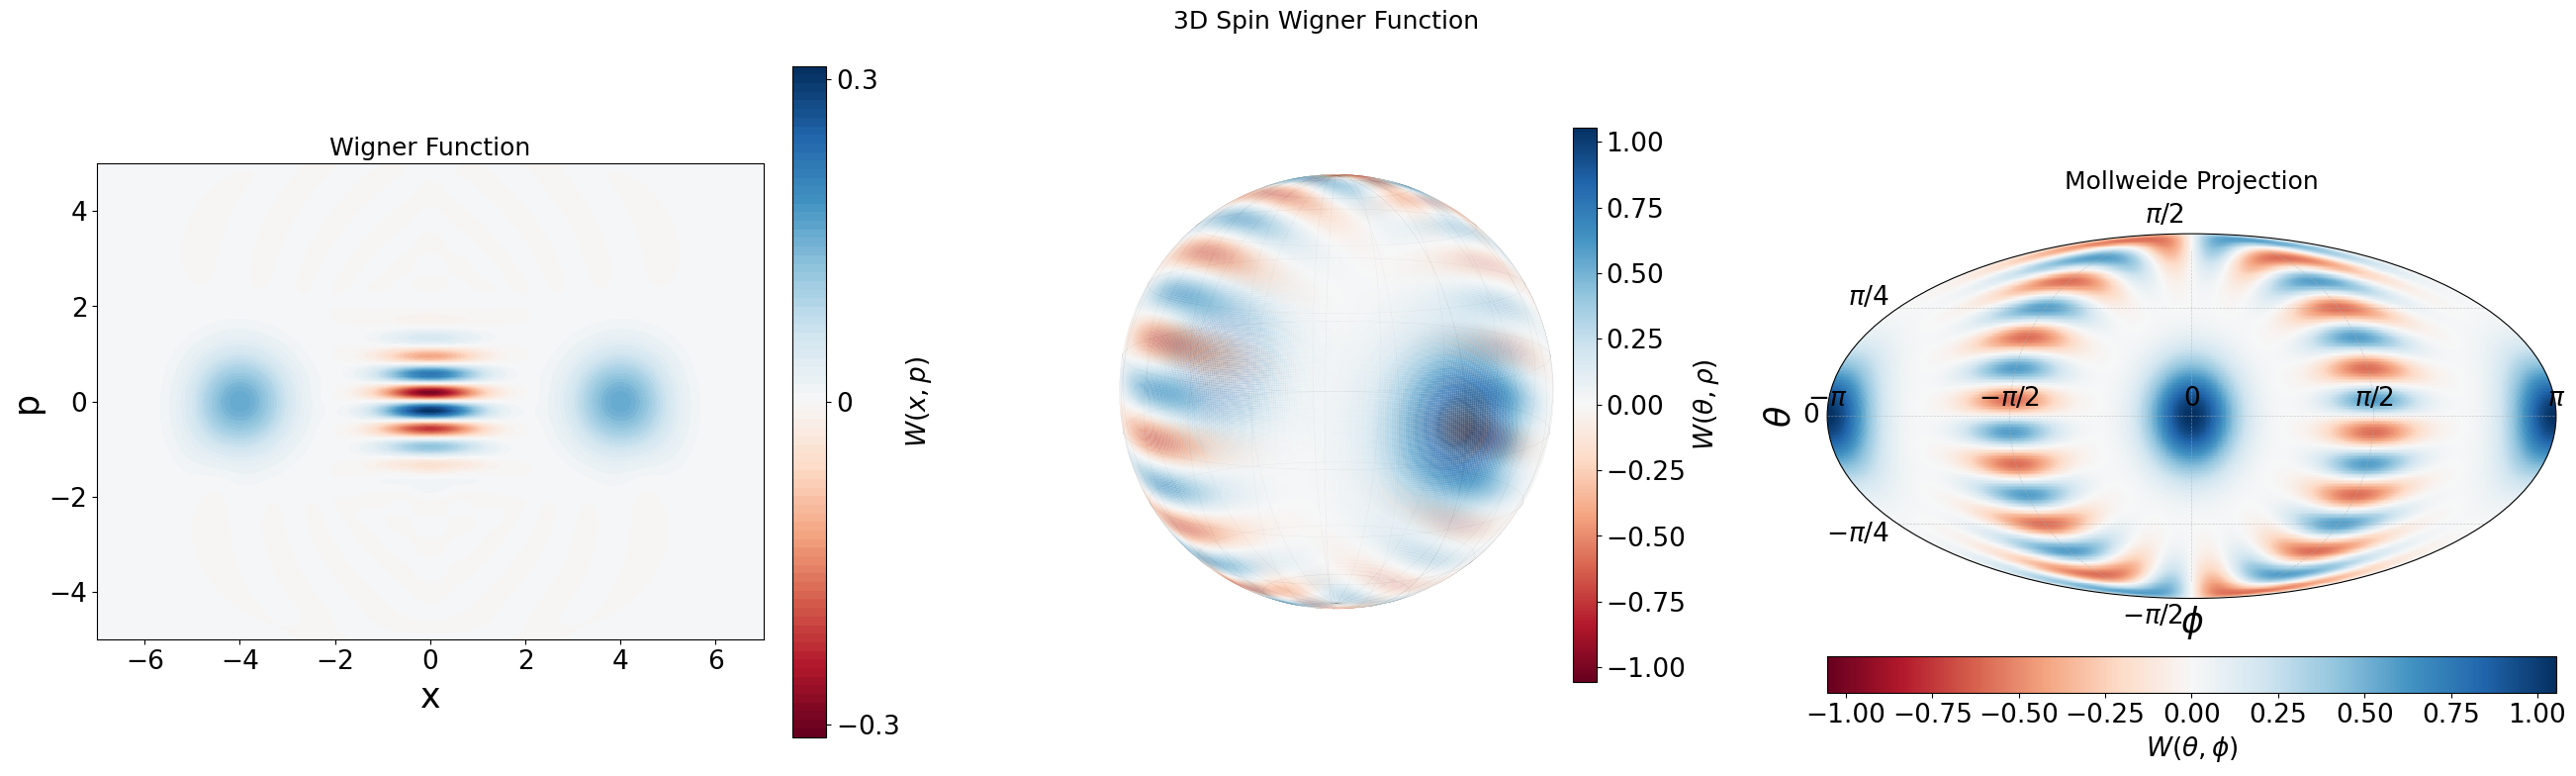

In [ ]:
#Figure 1: Plot the Wigner functions for the Schrodinger cat states and spin cat states

# Create a single figure with three subplots
fig = plt.figure(figsize=(24, 8)) # Adjusted for horizontal layout

# --- Plot 1: Wigner Function (coherent state) ---
ax1 = fig.add_subplot(1, 3, 1) # First subplot

N_wigner = 80
a_wigner = destroy(N_wigner)
psi_wigner = (coherent(N_wigner, 4/np.sqrt(2)) + 1j*coherent(N_wigner, -4/np.sqrt(2))).unit()
rho_wigner = psi_wigner * psi_wigner.dag()

# plot Wigner WITHOUT colorbar initially
plot_wigner(
    rho_wigner,
    xvec=np.linspace(-7, 7, 421),
    yvec=np.linspace(-5, 5, 301),
    colorbar=False,
    ax=ax1,
)

# get the QuadMesh created by plot_wigner
w = ax1.collections[0]

# symmetric normalization around zero
vmax_wigner = np.max(np.abs(w.get_array()))
norm_wigner = TwoSlopeNorm(vmin=-vmax_wigner, vcenter=0.0, vmax=vmax_wigner)
w.set_norm(norm_wigner)
w.set_rasterized(True)

# add custom colorbar for Plot 1
cbar1 = fig.colorbar(w, ax=ax1, fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=19)
cbar1.set_label(r'$W(x,p)$', fontsize=19)
cbar1.set_ticks([-0.3, 0.0, 0.3])
cbar1.set_ticklabels([r'$-0.3$', r'$0$', r'$0.3$'])

# axis styling for Plot 1
ax1.set_title("Wigner Function", fontsize=18)
ax1.set_xlabel("x", fontsize=25)
ax1.set_ylabel("p", fontsize=25)
ax1.set_xlim([-7, 7])
ax1.set_ylim([-5, 5])
ax1.set_xticks(np.linspace(-6, 6, 7))
ax1.set_yticks(np.linspace(-4, 4, 5))
ax1.set_aspect('equal', adjustable='box')


# --- 3D and 2D Wigner functions (Plot 2 and Plot 3) for spin cat states ---
#Define spin cat state
psi_spin = (spin_coherent(7, np.pi/2, 0)+1j*spin_coherent(7, np.pi/2, np.pi)).unit()

#Define \theta and \phi mesh
theta_vals_spin = np.linspace(0, np.pi, 300)
phi_vals_spin = np.linspace(0, 2*np.pi, 600)

#Compute Wigner function for the spin cat state
W_spin, THETA_spin, PHI_spin = spin_wigner(psi_spin, theta_vals_spin, phi_vals_spin)

# --- Plot 2: 3D Spin Wigner Function ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d') # Second subplot, 3D projection

# Convert spherical to cartesian
X_spin = np.sin(THETA_spin) * np.cos(PHI_spin)
Y_spin = np.sin(THETA_spin) * np.sin(PHI_spin)
Z_spin = np.cos(THETA_spin)

# Normalization for the colormap
vmax_spin_3d = np.max(W_spin)
vmin_spin_3d = -vmax_spin_3d
norm_spin_3d = TwoSlopeNorm(vmin=vmin_spin_3d, vcenter=0, vmax=vmax_spin_3d)

# Plot 3D Wigner surface
surf = ax2.plot_surface(
    X_spin, Y_spin, Z_spin,
    facecolors=cm.RdBu(norm_spin_3d(W_spin)),
    rstride=1, cstride=1,
    linewidth=0,
    shade=False,
    rasterized=True,
    alpha=0.75
)

# Latitude lines
for theta in np.linspace(0, np.pi, 10):
    x_lat = np.sin(theta) * np.cos(phi_vals_spin)
    y_lat = np.sin(theta) * np.sin(phi_vals_spin)
    z_lat = np.full_like(phi_vals_spin, np.cos(theta))
    ax2.plot(x_lat, y_lat, z_lat, color='k', linewidth=0.2, alpha=0.7)

# Longitude lines
for phi in np.linspace(0, 2*np.pi, 20):
    x_lon = np.sin(theta_vals_spin) * np.cos(phi)
    y_lon = np.sin(theta_vals_spin) * np.sin(phi)
    z_lon = np.cos(theta_vals_spin)
    ax2.plot(x_lon, y_lon, z_lon, color='k', linewidth=0.2, alpha=0.7)

# Add colorbar: create an axes manually, adjusted position for subplot 2
# [left, bottom, width, height] relative to figure
cax2 = fig.add_axes([0.67, 0.15, 0.01, 0.7]) # Positioned to the right of the 3D plot
mappable2 = cm.ScalarMappable(cmap=cm.RdBu, norm=norm_spin_3d)
mappable2.set_array(W_spin)
cbar2 = fig.colorbar(mappable2, cax=cax2)
cbar2.ax.tick_params(labelsize=19)
cbar2.set_label(r'$W(\theta,\rho)$', fontsize=19)


# Adjust view of the 3D sphere
ax2.view_init(elev=10, azim=-35)

# Clean background
ax2.set_axis_off()
ax2.grid(False)
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False

# Keep sphere proportional
r_max_spin = 1.0
ax2.set_xlim([-r_max_spin, r_max_spin])
ax2.set_ylim([-r_max_spin, r_max_spin])
ax2.set_zlim([-r_max_spin, r_max_spin])
ax2.set_box_aspect([1,1,1])
ax2.set_title("3D Spin Wigner Function", fontsize=18)

# --- Plot 3: Mollweide Projection (2D view of the 3D sphere) of the spin cat state Wigner function ---
ax3 = fig.add_subplot(1, 3, 3, projection='mollweide') # Third subplot, Mollweide projection

lon_spin = PHI_spin - np.pi               # longitude in [-pi, pi]
lat_spin = np.pi/2 - THETA_spin           # latitude in [-pi/2, pi/2]

# Colormap normalization
vmax_spin_mollweide = np.max(np.abs(W_spin))
norm_spin_mollweide = TwoSlopeNorm(vmin=-vmax_spin_mollweide, vcenter=0.0, vmax=vmax_spin_mollweide)

# Plot projected Wigner function
pcm = ax3.pcolormesh(
    lon_spin,
    lat_spin,
    W_spin,
    cmap=cm.RdBu,
    norm=norm_spin_mollweide,
    shading='auto',
    rasterized=True
)

# Grid & aesthetics
ax3.set_title("Mollweide Projection", fontsize=18, y=1.1)
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

ax3.set_xticks(np.linspace(-np.pi, np.pi, 5))
ax3.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
ax3.set_xlabel(r'$\phi$', fontsize=25)

ax3.set_yticks(np.linspace(-np.pi/2, np.pi/2, 5))
ax3.set_yticklabels([r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$'])
ax3.set_ylabel(r'$\theta$', fontsize=25)


# Colorbar for Plot 3
cbar3 = fig.colorbar(pcm, ax=ax3, orientation='horizontal', pad=0.08)
cbar3.set_label(r'$W(\theta,\phi)$', fontsize=19)
cbar3.ax.tick_params(labelsize=19)

# Adjusted plot frame for more space on the right
plt.tight_layout(rect=[0, 0, 1.1, 1])

#Save the plot as .svg file for further polishing
#fig.savefig("combined_wigner_plots.svg", format="svg")

plt.show()

In [ ]:
#Figure 2: Fidelity v.s. time for different combinations of engineered dissipation and unwanted noise

#Claim my dimension
dim=5

#The parameter N of the two-mode binomial state
N=dim-1

#Define the bosonic annihilation operators \hat{a} and \hat{b}
a=tensor(destroy(dim),qeye(dim))
b=tensor(qeye(dim),destroy(dim))

#Define the two-mode binomial coherent state
def psi(k,xi):
    return sum(np.sqrt(math.comb(k,n))*(xi)**(n)*tensor(basis(dim,n),basis(dim,k-n)) for n in range(k+1)).unit()

#Define the logical bit 0 and 1
q0=psi(N,-1)
q1=psi(N,1)

#Define the Pauli operators \sigma_x, \sigma_y, and \sigma_z
sig_x=q0*q1.dag()+q1*q0.dag()
sig_y=-1j*q0*q1.dag()+1j*q1*q0.dag()
sig_z=q1*q1.dag()-q0*q0.dag()

#Define the initial state of the system
s_0=(q0+q1).unit()
rho_0=s_0*s_0.dag()

#Define the target state
s_1=(q0+q1).unit()
rho_1=s_1*s_1.dag()

#Define the engineered jump operators
L1=a.dag()*(a.dag()*a+b.dag()*b-N)
L2=a**2-b**2

#Define the jump rates for the noise operator, assuming that of the engineered jump operators \kappa=1; \gamma will be rescaled by \kappa.
gamma_a=np.linspace(0.01, 0.2, 191)
gamma_b=gamma_a
gamma_phia=gamma_a
gamma_phib=gamma_a

#Define the time range for the plot
times1=np.linspace(0,2*np.pi,101)

#Print out the time and fidelity data points for different cases
times=np.linspace(0,10,101)
result0 = mesolve(0*a, rho_0, times, c_ops=[L1, L2], e_ops=[rho_1], options={"progress_bar":True})
result1 = mesolve(0*a, rho_0, times, c_ops=[L1, L2, np.sqrt(0.03)*a, np.sqrt(0.03)*a.dag()*a, np.sqrt(0.03)*b.dag()*b], e_ops=[rho_1], options={"progress_bar":True})
result2 = mesolve(0*a, rho_0, times, c_ops=[L1, L2, np.sqrt(0.01)*a, np.sqrt(0.01)*a.dag()*a, np.sqrt(0.01)*b.dag()*b, np.sqrt(0.01)*b], e_ops=[rho_1], options={"progress_bar":True})
for t,x,y,z in zip(times, result0.expect[0], result1.expect[0], result2.expect[0]):
    print (t,x,y,z)

#Note that the printed data points might contain square brackets [...], and one could always paste it to excel or origin to remove them.

10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.01s. Est. time left: 00:00:00:00
30.0%. Run time:   0.01s. Est. time left: 00:00:00:00
40.0%. Run time:   0.02s. Est. time left: 00:00:00:00
50.0%. Run time:   0.02s. Est. time left: 00:00:00:00
60.0%. Run time:   0.02s. Est. time left: 00:00:00:00
70.0%. Run time:   0.03s. Est. time left: 00:00:00:00
80.0%. Run time:   0.03s. Est. time left: 00:00:00:00
90.0%. Run time:   0.04s. Est. time left: 00:00:00:00
100.0%. Run time:   0.04s. Est. time left: 00:00:00:00
Total run time:   0.04s
10.0%. Run time:   0.01s. Est. time left: 00:00:00:00
20.0%. Run time:   0.02s. Est. time left: 00:00:00:00
30.0%. Run time:   0.03s. Est. time left: 00:00:00:00
40.0%. Run time:   0.04s. Est. time left: 00:00:00:00
50.0%. Run time:   0.04s. Est. time left: 00:00:00:00
60.0%. Run time:   0.05s. Est. time left: 00:00:00:00
70.0%. Run time:   0.05s. Est. time left: 00:00:00:00
80.0%. Run time:   0.06s. Est. time left: 00:00:00:00
90.

In [ ]:
#Figure 3: Fidelity v.s. time for different N

# Parameters
N_values = range(3, 11)

#Decay rate of unwatned noise
kap2 = 0.03

#Time (x-axis) span for the plot
times = np.linspace(0, 3 * np.pi, 500)

# Dictionary to store results
data_points = {'Time/pi': times / np.pi}

for N in N_values:
    print(f"Calculating for N={N}...")

    #The necessarily used dimension of Hilbert space is set to a bit higher than N
    dim = N + 2

    #Define bosonic annihilation operators \hat{a} and \hat{b}
    a = tensor(destroy(dim), qeye(dim))
    b = tensor(qeye(dim), destroy(dim))

    #Define the two-mode binomial coherent state
    def psi_func(k, xi):
        return sum(np.sqrt(math.comb(k, n)) * (xi)**(n) * tensor(basis(dim, n), basis(dim, k-n)) for n in range(k+1)).unit()

    #Define the logical bits 0 and 1
    q0 = psi_func(N, -1)
    q1 = psi_func(N, 1)

    #Define the initial state
    s_0 = tensor(basis(dim, 0), basis(dim, 0))
    rho_0 = s_0 * s_0.dag()

    #Define engineered jump operators
    L1 = a.dag() * (a.dag() * a + b.dag() * b - N)
    L2 = a**2 - b**2

    #Define the channels needed for the simulation
    c_ops = [L1, L2, np.sqrt(kap2) * a, np.sqrt(kap2) * a.dag() * a, np.sqrt(kap2) * b.dag() * b]

    #Since the prepared even/odd two-mode binomial cat states depend on the value of N, the fidelities are computed with respect to even cat state if N=even, and vice versa.
    if N % 2 == 0:
        target_state = (q0 + q1).unit()
    else:
        target_state = (q0 - q1).unit()

    rho_target = target_state * target_state.dag()

    # Solve master equation
    result = mesolve(0 * a, rho_0, times, c_ops, e_ops=[rho_target])

    # Store results for this N
    data_points[f'N={N}'] = result.expect[0]

# Create DataFrame for clean printing
df_results = pd.DataFrame(data_points)

# Set pandas options to see all rows/columns if needed, then print
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)
print("\nSimulation Complete. Results Table:")
print(df_results.to_string(index=False))

Calculating for N=3...
Calculating for N=4...
Calculating for N=5...
Calculating for N=6...
Calculating for N=7...
Calculating for N=8...
Calculating for N=9...
Calculating for N=10...

Simulation Complete. Results Table:
 Time/pi      N=3      N=4      N=5          N=6          N=7          N=8          N=9         N=10
0.000000 0.000000 0.000000 0.000000 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
0.006012 0.000055 0.000008 0.000002 4.368613e-07 1.566350e-07 6.843089e-08 3.508407e-08 2.045831e-08
0.012024 0.000402 0.000101 0.000036 1.697343e-05 9.640606e-06 6.321883e-06 4.604245e-06 3.615519e-06
0.018036 0.001236 0.000427 0.000203 1.203286e-04 8.325056e-05 6.397458e-05 5.275545e-05 4.558097e-05
0.024048 0.002675 0.001131 0.000636 4.320630e-04 3.319061e-04 2.761829e-04 2.420823e-04 2.197211e-04
0.030060 0.004777 0.002326 0.001463 1.082141e-03 8.861211e-04 7.745832e-04 7.075111e-04 6.675117e-04
0.036072 0.007556 0.004083 0.002779 2.178786e-03 1.865077e-03 1.691754e

In [ ]:
#Figure 5: Expectation values of \sigma_x, \sigma_y and \sigma_z in the log time scale

#Dimension of the Hilbert space
dim=5

#The parameter N of the two-mode binomial states
N=dim-1

#Define bosonic annihilation operators \hat{a} and \hat{b}
a=tensor(destroy(dim),qeye(dim))
b=tensor(qeye(dim),destroy(dim))

#Define the two-mode binomial coherent state
def psi(k,xi):
    return sum(np.sqrt(math.comb(k,n))*(xi)**(n)*tensor(basis(dim,n),basis(dim,k-n)) for n in range(k+1)).unit()

#Define the logical bits 0 and 1
q0=psi(N,-1)
q1=psi(N,1)

#Define the Pauli operators \sigma_x, \sigma_y, and \sigma_z
sig_x=q0*q1.dag()+q1*q0.dag()
sig_y=-1j*q0*q1.dag()+1j*q1*q0.dag()
sig_z=q1*q1.dag()-q0*q0.dag()

#Define the initial state of the system
s_0=(q0+q1).unit()
rho_0=s_0*s_0.dag()

#Define the target state
s_1=(q0+q1).unit()
rho_1=s_1*s_1.dag()

#Define engineered jump operators
L1=a.dag()*(a.dag()*a+b.dag()*b-N)
L2=a**2-b**2

#Define the jump rate (kap1) for the engineered jump operators, and (kap2) for the unwanted noise jump operators.
kap1=1
kap2=0.01

#Time (x-axis) span for the plot
times=np.linspace(0,25*np.pi,1001)

#Simulating the Lindblad master equation
result0 = mesolve(0*a, rho_0, times, [np.sqrt(kap2)*a, np.sqrt(kap2)*b, np.sqrt(kap2)*a.dag()*a, np.sqrt(kap2)*b.dag()*b], [rho_0], options={"progress_bar":True})
result1 = mesolve(0*a, rho_0, times, [np.sqrt(kap1)*L1, np.sqrt(kap1)*L2, np.sqrt(kap2)*a, np.sqrt(kap2)*b, np.sqrt(kap2)*a.dag()*a, np.sqrt(kap2)*b.dag()*b], [rho_0], options={"progress_bar":True})
result2 = mesolve(0*a, rho_0, times, [np.sqrt(kap1)*L1, np.sqrt(kap1)*L2, np.sqrt(kap2)*a, np.sqrt(kap2)*a.dag()*a, np.sqrt(kap2)*b.dag()*b], [rho_0], options={"progress_bar":True})
for x, y, z in zip(np.array(result0.expect).T,np.array(result1.expect).T,np.array(result2.expect).T):
    print (x, y, z)

#Print out the time data points in units of pi
for x in times:
    print (x/np.pi)

simulating case 1
simulating case 2
simulating case 3
simulating case 4

--- Combined Results Table (Time and Sensitivity per Case) ---
             t1          res1           t2           res2            t3      res3         t4           res4
0      0.010186  7.443777e+04     0.010335   27357.710083      0.060364  0.609384   0.010186   37221.196766
1      0.010376  5.336401e+04     0.010507  101758.577625      0.061205  0.603240   0.010569   66275.290200
2      0.010967  4.396734e+04     0.010681  118951.215710      0.062057  0.598243   0.010766   31037.727278
3      0.011171  3.906626e+04     0.011039   74654.086057      0.062921  0.592370   0.010967  175925.804280
4      0.011379  1.069575e+05     0.011222   40816.664261      0.063798  0.586735   0.011171   48851.791382
5      0.011591  5.796669e+04     0.011598   94870.827160      0.064686  0.581604   0.011379  107006.432681
6      0.011807  1.246783e+05     0.011790   50621.361439      0.065587  0.575643   0.011591   77329.691290


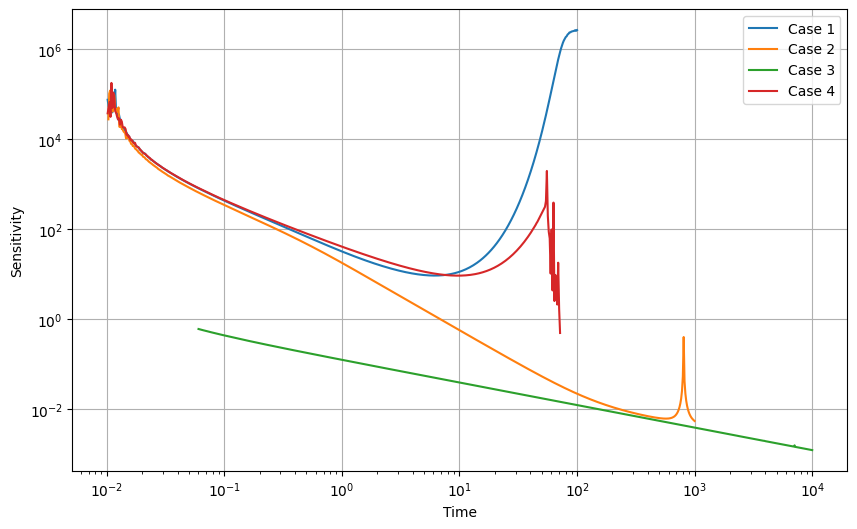

In [ ]:
#Figure 6: Sensitivity v.s. time for different combinations of engineered dissipation and unwanted noise

#Dimension of the Hilbert space
dim=9

#The parameter N of the two-mode binomial states
N=dim-1

#Define bosonic annihilation operators \hat{a} and \hat{b}
a=tensor(destroy(dim),qeye(dim))
b=tensor(qeye(dim),destroy(dim))

#Define the two-mode binomial coherent state
def psi(k,xi):
    return sum(np.sqrt(math.comb(k,n))*(xi)**(n)*tensor(basis(dim,n),basis(dim,k-n)) for n in range(k+1)).unit()

#Define the logical bits 0 and 1
q0=psi(N,-1)
q1=psi(N,1)

#Define the Pauli operators \sigma_x, \sigma_y, and \sigma_z
sig_z=q1*q1.dag()-q0*q0.dag()
sig_x=q0*q1.dag()+q1*q0.dag()
sig_y=-1j*q0*q1.dag()+1j*q1*q0.dag()

#Define the initial state of the system
s_0=(q0+q1).unit()
rho_0=s_0*s_0.dag()

#Define the target state
s_1=tensor(basis(dim,0), basis(dim,N))
rho_1=s_1*s_1.dag()

#Define engineered jump operators
L1=a.dag()*(a.dag()*a+b.dag()*b-N)
L2=a**2-b**2

#The small delta (or \theta) as in the derivatives dP/d\theta for computing the derivatives
delta=10**(-8)

#The weak beam-splitter interaction used to measure the flux accross the circuit
#We note that this choice of weak Omega is also to make sure that the unitary oscillations in the sensitivity plot occurs at a bit later time \sim 10^2 or 10^3.
#Such oscillations behave essentially as some fast oscillations in the log time scales (similar to those fast oscillations in rotating wave approximations), and can later be manually removed when plotting the sensitivity plot.
Omega=0.0005

#The beam-splitter Hamiltonian
H=Omega/2*(a.dag()*b+a*b.dag())

#The parameter P in the sensitivity definition
mathcal_P=rho_0

#Define the jump rate (kap1) for the engineered jump operators, and (kap2) for the unwanted noise jump operators.
kap1=1
kap2=0.03

np.set_printoptions(precision=15)

# Define independent time ranges for each dissipative case
t_int_case1 = np.logspace(-2, 2, 500)
t_int_case2 = np.logspace(-2, 3, 700)
t_int_case3 = np.logspace(-2, 4, 1000)
t_int_case4 = np.logspace(-2, 2, 500)

def compute_delta_theta(c_ops_list, time_array):
    opts = {'nsteps': 5000}
    # Base simulation
    result_P = mesolve(H, rho_0, time_array, c_ops_list, e_ops=[mathcal_P], options=opts)
    P = result_P.expect[0]
    # Perturbed simulation
    epsilon = delta
    H_plus = (Omega + epsilon)/2*(a.dag()*b + a*b.dag())
    result_P_plus = mesolve(H_plus, rho_0, time_array, c_ops_list, e_ops=[mathcal_P], options=opts)
    P_plus = result_P_plus.expect[0]
    # Numerical derivative
    dP_dtheta = abs(P_plus - P) / epsilon
    # Masking for stability
    # Here, we note that since the plot is plotted in log scales, at very small time t\sim 10^{-2} and very large time t\sim 10^{3}, the parameters P or change dP/d\theta can be extremely small that is no longer numerically reliable, hence we will mask them.
    valid_mask = (P > 1e-8) & (P < 1 - 1e-8) & (dP_dtheta > 1e-8)
    t_masked = time_array[valid_mask]
    sens_masked = np.sqrt(P[valid_mask] * (1 - P[valid_mask])) / dP_dtheta[valid_mask] * np.sqrt(t_masked)
    return t_masked, sens_masked

# Simulations
print("simulating case 1")
t1, res1 = compute_delta_theta([np.sqrt(kap1)*L1, np.sqrt(kap1)*L2, np.sqrt(kap2)*a, np.sqrt(kap2)*b, np.sqrt(kap2)*a.dag()*a, np.sqrt(kap2)*b.dag()*b], t_int_case1)
print("simulating case 2")
t2, res2 = compute_delta_theta([np.sqrt(kap1)*L1, np.sqrt(kap1)*L2, np.sqrt(kap2)*a, np.sqrt(kap2)*a.dag()*a, np.sqrt(kap2)*b.dag()*b], t_int_case2)
print("simulating case 3")
t3, res3 = compute_delta_theta([], t_int_case3)
print("simulating case 4")
t4, res4 = compute_delta_theta([np.sqrt(kap2)*a, np.sqrt(kap2)*b, np.sqrt(kap2)*a.dag()*a, np.sqrt(kap2)*b.dag()*b], t_int_case4)

# Create independent DataFrames for each case to maintain specific column order (t, res)
df1 = pd.DataFrame({'t1': t1, 'res1': res1})
df2 = pd.DataFrame({'t2': t2, 'res2': res2})
df3 = pd.DataFrame({'t3': t3, 'res3': res3})
df4 = pd.DataFrame({'t4': t4, 'res4': res4})

# Concatenate horizontally (axis=1) without merging on index
# This creates 8 columns: t1, res1, t2, res2, t3, res3, t4, res4
combined_output_df = pd.concat([df1, df2, df3, df4], axis=1)

# Print the results table
print("\n--- Combined Results Table (Time and Sensitivity per Case) ---")
print(combined_output_df.to_string())

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t1, res1, label='Case 1')
plt.plot(t2, res2, label='Case 2')
plt.plot(t3, res3, label='Case 3')
plt.plot(t4, res4, label='Case 4')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Time'); plt.ylabel('Sensitivity'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
#Figure 7: Stationary fidelity v.s. decay rate gamma for different types of noise
#Claim my dimension
dim=7

#The parameter N of the two-mode binomial state
N=dim-1

#Define the bosonic annihilation operators \hat{a} and \hat{b}
a=tensor(destroy(dim),qeye(dim))
b=tensor(qeye(dim),destroy(dim))

#Define the two-mode binomial coherent state
def psi(k,xi):
    return sum(np.sqrt(math.comb(k,n))*(xi)**(n)*tensor(basis(dim,n),basis(dim,k-n)) for n in range(k+1)).unit()

#Define the logical bit 0 and 1
q0=psi(N,-1)
q1=psi(N,1)

#Define the Pauli operators \sigma_x, \sigma_y, and \sigma_z
sig_x=q0*q1.dag()+q1*q0.dag()
sig_y=-1j*q0*q1.dag()+1j*q1*q0.dag()
sig_z=q1*q1.dag()-q0*q0.dag()

#Define the initial state of the system
s_0=(q0+q1).unit()
rho_0=s_0*s_0.dag()

#Define the target state
s_1=(q0+q1).unit()
rho_1=s_1*s_1.dag()

#Define the engineered jump operators
L1=a.dag()*(a.dag()*a+b.dag()*b-N)
L2=a**2-b**2

#Define the jump rates for the noise operator, assuming that of the engineered jump operators \kappa=1; \gamma will be rescaled by \kappa.
gamma_a=np.linspace(0.01, 0.2, 191)
gamma_b=gamma_a
gamma_phia=gamma_a
gamma_phib=gamma_a

#Define the time range for the plot
times1=np.linspace(0,2*np.pi,101)

#Print out the fidelity data points for different cases
for x,y,z,w in zip(gamma_a, gamma_b, gamma_phia, gamma_phib):
    result_x = mesolve(0*a, rho_0, times1, c_ops=[L1, L2, np.sqrt(x)*a], e_ops=[rho_1])
    result_y = mesolve(0*a, rho_0, np.linspace(0,1/y,301), c_ops=[L1, L2, np.sqrt(y)*b], e_ops=[rho_1])
    result_z = mesolve(0*a, rho_0, times1, c_ops=[L1, L2, np.sqrt(z)*a.dag()*a], e_ops=[rho_1])
    result_w = mesolve(0*a, rho_0, times1, c_ops=[L1, L2, np.sqrt(w)*b.dag()*b], e_ops=[rho_1])
    print(result_x.expect[0][100], result_y.expect[0][100], result_z.expect[0][100], result_w.expect[0][100])

#Print out the time data points
for x in gamma_a:
    print (x)